# Seasonal plots

On a time plot, years march left to right — but can you tell *which month* drives the peak without tracing individual years by hand?

In this lesson you will:

- draw a simple time series plot with [seaborn](https://seaborn.pydata.org/);
- explore yearly seasonality with [Prophet](https://facebook.github.io/prophet/);
- build **seasonal plots** that stack each year on top of the others so within-year patterns jump out; and
- read daily, weekly, and yearly patterns in half-hourly electricity demand.

Adapted from [Forecasting: Principles and Practice (3rd ed), §2.4](https://otexts.com/fpp3/seasonal-plots.html).

You can also [▶️ watch the walkthrough on YouTube (Skip to 6:40)](https://www.youtube.com/watch?v=8DFwIY0-Pf8&list=PLyCNZ_xXGzpm7W9jLqbIyBAiSO5jDwJeE&index=9&t=400).

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Docs: https://pandas.pydata.org/docs/ | https://seaborn.pydata.org/
sns.set_theme(style="whitegrid")

LESSON_DIR = Path().resolve()
DATA_DIR = LESSON_DIR.parent / "data"


## Multiple seasonal periods

Half-hourly electricity demand for Victoria, Australia (Melbourne local time), from 2012 to 2015 — about 52,608 observations. Besides `Demand` (megawatts), the table includes `Temperature`, `Date`, and `Holiday`.


In [2]:
vic_elec = pd.read_csv(
    DATA_DIR / "vic_elec.csv",
    parse_dates=["Time", "Date"],
    index_col="Time",
)
# `Time` is UTC in the CSV; `Date` is the Melbourne calendar date — convert for local-time plots.
vic_elec.index = (
    vic_elec.index.tz_localize("UTC")
    .tz_convert("Australia/Melbourne")
    .tz_localize(None)
)

vic_elec

,Demand,Temperature,Date,Holiday
Time,,,,
2012-01-01 00:00:00,4382.825174,21.40,2012-01-01,True
2012-01-01 00:30:00,4263.365526,21.05,2012-01-01,True
2012-01-01 01:00:00,4048.966046,20.70,2012-01-01,True
2012-01-01 01:30:00,3877.563330,20.55,2012-01-01,True
2012-01-01 02:00:00,4036.229746,20.40,2012-01-01,True
...,...,...,...,...
2014-12-31 21:30:00,3873.448714,19.00,2014-12-31,False
2014-12-31 22:00:00,3791.637322,18.50,2014-12-31,False
2014-12-31 22:30:00,3724.835666,17.70,2014-12-31,False


### Time plot

Start with a plain **time plot** of the whole series. With three years of half-hourly readings the daily and weekly cycles blur into a dense band, but the broad yearly shape — summer and winter demand peaks — is already visible.


In [ ]:
vic_time = vic_elec.reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.lineplot(
    data=vic_time,
    x="Time",
    y="Demand",
    linewidth=0.5,
    ax=ax,
)
ax.set(
    title="Electricity demand: Victoria",
    ylabel="MWh",
    xlabel="",
)
plt.show()

### Yearly pattern

Each line is one calendar year; the x-axis counts half-hour slots from 1 January.


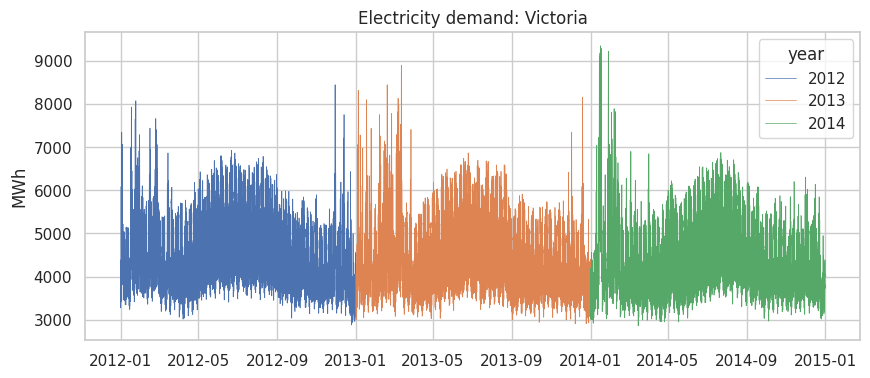

In [88]:
vic_year = vic_elec.reset_index()
vic_year["year"] = vic_year["Time"].dt.year.astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.lineplot(
    data=vic_year,
    x="Time",
    y="Demand",
    hue="year",
    linewidth=0.5,
    ax=ax,
)
ax.set(
    title="Electricity demand: Victoria",
    ylabel="MWh",
    xlabel="",
)
plt.show()

Reading the time plot:

- Half-hourly readings blur into a **dense band** — individual daily cycles are not readable at this scale.
- **Summer** and **winter** swings still show up as wider, spikier stretches across each calendar year.
- To compare years on the same within-year axis we need a **seasonal plot** — the R equivalent is `gg_season(Demand, period = "year")` (Figure 2.7 in FPP3).


### Per weather season pattern

Now color the same time plot by **Melbourne season**:

- **Summer**: December-February
- **Autumn**: March-May
- **Winter**: June-August
- **Spring**: September-November

This makes the yearly rhythm easier to see before we reshape the data into seasonal plots.


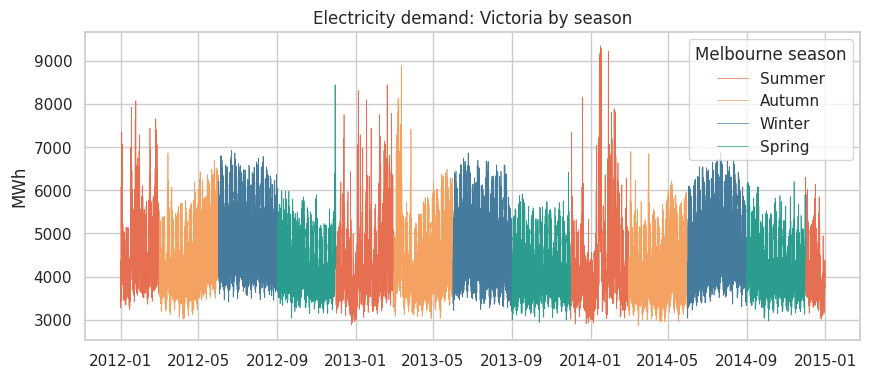

In [86]:
vic_season = vic_time.copy()
month = vic_season["Time"].dt.month

season_map = {
    12: "Summer",
    1: "Summer",
    2: "Summer",
    3: "Autumn",
    4: "Autumn",
    5: "Autumn",
    6: "Winter",
    7: "Winter",
    8: "Winter",
    9: "Spring",
    10: "Spring",
    11: "Spring",
}
season_order = ["Summer", "Autumn", "Winter", "Spring"]
vic_season["season"] = pd.Categorical(
    month.map(season_map),
    categories=season_order,
    ordered=True,
)

# Keep each seasonal stretch separate so the line does not connect across gaps.
season_year = vic_season["Time"].dt.year.mask(month.eq(12), vic_season["Time"].dt.year + 1)
vic_season["season_run"] = vic_season["season"].astype(str) + " " + season_year.astype(str)

season_palette = {
    "Summer": "#E76F51",
    "Autumn": "#F4A261",
    "Winter": "#457B9D",
    "Spring": "#2A9D8F",
}

fig, ax = plt.subplots(figsize=(10, 4))
ax = sns.lineplot(
    data=vic_season,
    x="Time",
    y="Demand",
    hue="season",
    units="season_run",
    estimator=None,
    palette=season_palette,
    linewidth=0.5,
    ax=ax,
)
ax.set(
    title="Electricity demand: Victoria by season",
    ylabel="MWh",
    xlabel="",
)
ax.legend(title="Melbourne season")
plt.show()

With half-hourly data there are **multiple seasonal patterns** at different scales: position within the **year**, within the **week**, and within each **day**. We reshape the timestamps for each pattern, then draw each cycle with `sns.lineplot` — the Python equivalent of R's `gg_season()`.


### Yearly pattern (overlaid)

Each line is one calendar year; the x-axis counts **half-hour slots from 1 January** — equivalent to `gg_season(Demand, period = "year")` in R (Figure 2.7).

Shaded bands and x-axis labels mark **Melbourne seasons** (Southern hemisphere):

- **Summer**: December–February
- **Autumn**: March–May
- **Winter**: June–August
- **Spring**: September–November

December at the end of the axis is the second summer band within the same calendar year.


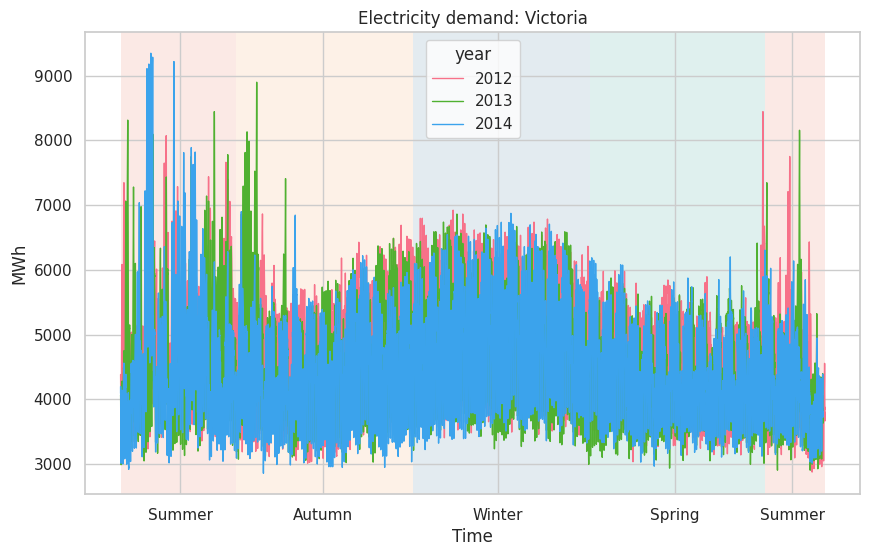

In [104]:
# Reuse vic_year from the yearly-pattern cell; count half-hour slots from 1 January.
year_start = pd.to_datetime(vic_year["year"] + "-01-01")
vic_year["slot"] = (
    (vic_year["Time"] - year_start) / pd.Timedelta(minutes=30)
).astype(int)

# Melbourne season boundaries on a calendar-year axis (Southern hemisphere).
ref_year = pd.Timestamp("2012-01-01")
year_end_slot = int(
    (pd.Timestamp("2012-12-31 23:30") - ref_year) / pd.Timedelta(minutes=30)
) + 1


def to_slot(date_str):
    return int((pd.Timestamp(date_str) - ref_year) / pd.Timedelta(minutes=30))


season_spans = [
    ("Summer", "2012-01-01", "2012-03-01"),
    ("Autumn", "2012-03-01", "2012-06-01"),
    ("Winter", "2012-06-01", "2012-09-01"),
    ("Spring", "2012-09-01", "2012-12-01"),
    ("Summer", "2012-12-01", None),  # December
]
season_mids = [
    ("Summer", "2012-02-01"),
    ("Autumn", "2012-04-15"),
    ("Winter", "2012-07-15"),
    ("Spring", "2012-10-15"),
    ("Summer", "2012-12-15"),
]

fig, ax = plt.subplots(figsize=(10, 6))
for name, start, end in season_spans:
    x0 = to_slot(start)
    x1 = year_end_slot if end is None else to_slot(end)
    ax.axvspan(x0, x1, color=season_palette[name], alpha=0.15, linewidth=0, zorder=0)

ax = sns.lineplot(
    data=vic_year,
    x="slot",
    y="Demand",
    hue="year",
    palette="husl",
    linewidth=1,
    ax=ax,
    zorder=1,
)
slot_ticks = [to_slot(date_str) for _, date_str in season_mids]
ax.set(
    title="Electricity demand: Victoria",
    ylabel="MWh",
    xlabel="Time",
    xticks=slot_ticks,
    xticklabels=[name for name, _ in season_mids],
)
plt.show()

Reading the yearly pattern (Figure 2.7):

- **Summer** months in the Southern hemisphere (January, February, December) show high variation and frequent spikes — hot days drive air-conditioning load.
- **Autumn** demand is lower than summer.
- **Winter** months (June, July, August) show higher, more variable demand.
- **Spring** is relatively stable — lower than winter and summer.
- Much of this yearly structure is also visible on the time plot, so this view adds less new information than the daily and weekly plots below.


### Weekly pattern

Each line is one ISO week; the x-axis counts half-hour slots from the start of that week.


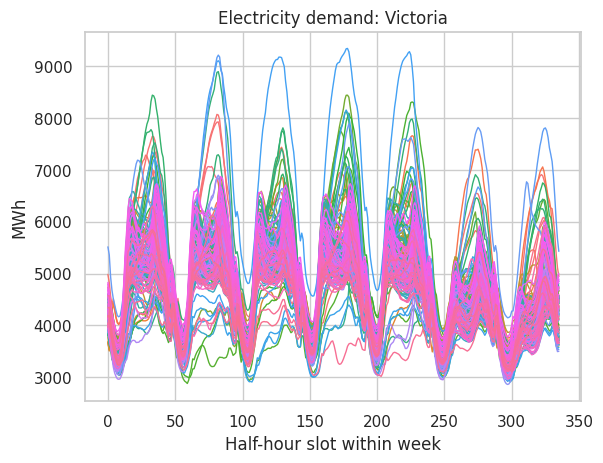

In [ ]:
vic_week = vic_elec.reset_index()
iso = vic_week["Time"].dt.isocalendar()
vic_week["week"] = iso.year.astype(str) + "-W" + iso.week.astype(str).str.zfill(2)
week_start = vic_week["Time"].dt.to_period("W-SUN").dt.start_time
vic_week["slot"] = (
    (vic_week["Time"] - week_start) / pd.Timedelta(minutes=30)
).astype(int)

ax = sns.lineplot(
    data=vic_week,
    x="slot",
    y="Demand",
    hue="week",
    legend=False,
    linewidth=1,
)
ax.set(
    title="Electricity demand: Victoria",
    ylabel="MWh",
    xlabel="Half-hour slot within week",
)
plt.show()

Reading the weekly pattern:

- **Weekend** demand is lower than on **weekdays**.
- Weekends follow a different intraday shape: two peaks, but the morning peak is lower than the evening peak — especially on Sunday.
- If you build a forecasting model, allow for **different seasonal patterns** on weekends versus weekdays.
- Like the daily pattern, these features **cannot** be seen on the time plot.


### Daily pattern

Each line is one calendar day; the x-axis is the half-hour slot within that day.


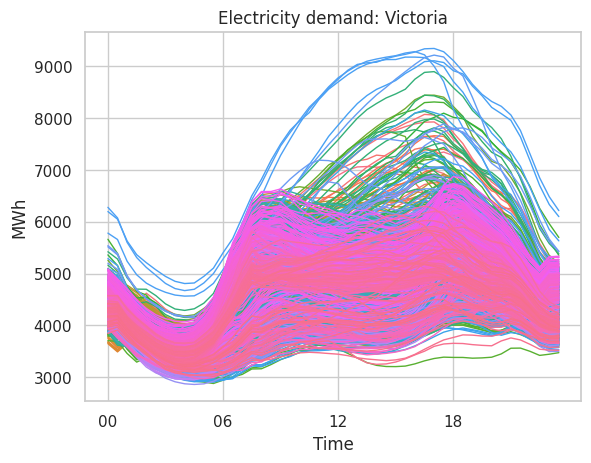

In [9]:
vic_day = vic_elec.reset_index()
vic_day["day"] = vic_day["Time"].dt.strftime("%Y-%m-%d")
# Half-hour slot index within each calendar day (0 = midnight)
vic_day["slot"] = vic_day["Time"].dt.hour * 2 + vic_day["Time"].dt.minute // 30

ax = sns.lineplot(
    data=vic_day,
    x="slot",
    y="Demand",
    hue="day",
    legend=False,  # too many days for a useful legend
    linewidth=1,
)
# Match FPP-style hour labels: 00, 06, 12, 18
slot_ticks = [0, 12, 24, 36]
time_labels = ["00", "06", "12", "18"]
ax.set(
    title="Electricity demand: Victoria",
    ylabel="MWh",
    xlabel="Time",
    xticks=slot_ticks,
    xticklabels=time_labels,
)
plt.show()

Reading the daily pattern:

- Demand is lowest around **4 AM**, when most people are asleep.
- From about **6 AM** demand rises as people wake up; it dips mid-day, then climbs around **5–6 PM** as people return home.
- Demand falls through the evening.
- On very hot days the within-day pattern can spike far above the usual shape.
- The three days with 25 half-hour steps above the usual pattern are when daylight saving **ended** (an extra hour). Three 23-hour days (DST start) hide beneath the other lines.
- These intraday patterns **cannot** be read from the time plot.


### Daily pattern by weather season

Reuse the same daily slots, but add `col="season"` so seaborn draws **one panel per Melbourne weather season** — Summer, Autumn, Winter, Spring.

`col` is a figure-level argument, so we call `sns.relplot(..., kind="line", col="season")`; seaborn runs `sns.lineplot` on each panel.

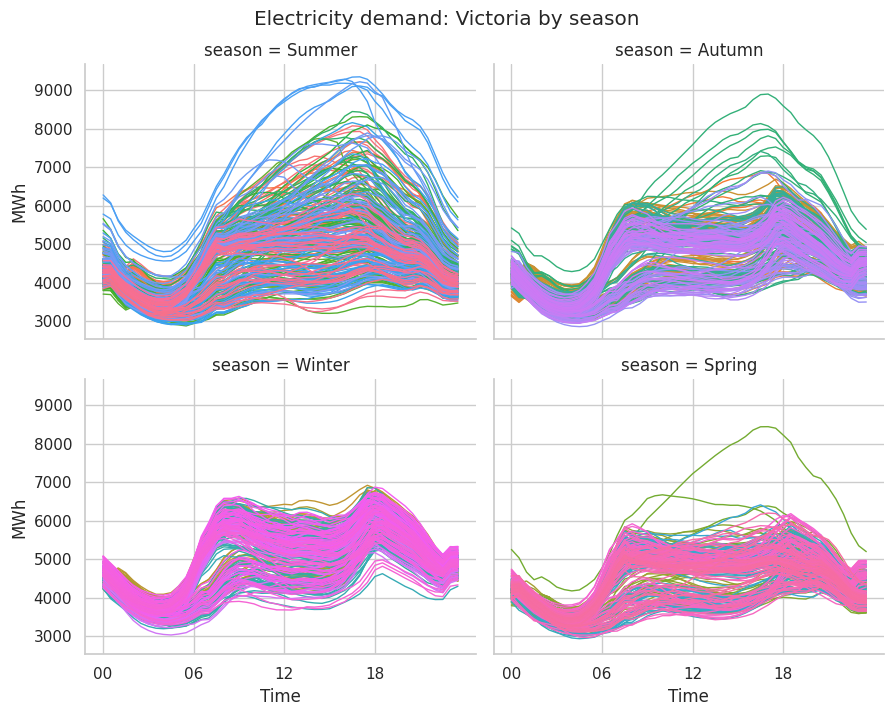

In [19]:
# Reuse season_map / season_order from the weather-season time plot.
vic_day_season = vic_day.assign(
    season=pd.Categorical(
        vic_day["Time"].dt.month.map(season_map),
        categories=season_order,
        ordered=True,
    ),
)

g = sns.relplot(
    data=vic_day_season,
    kind="line",
    x="slot",
    y="Demand",
    hue="day",
    col="season",  # one panel per Melbourne weather season
    col_order=season_order,
    col_wrap=2,
    legend=False,  # too many days for a useful legend
    linewidth=1,
    facet_kws={"sharey": True},
    height=3.5,
    aspect=1.3,
)
g.set_axis_labels("Time", "MWh")
g.set(xticks=slot_ticks, xticklabels=time_labels)
g.fig.suptitle("Electricity demand: Victoria by season", y=1.02)
plt.show()

Reading the daily pattern by weather season:

- The **same within-day shape** (low at ~4 AM, morning rise, evening peak) appears in every panel — weather does not erase the daily cycle.
- **Summer** has the most extreme spikes: hot days drive air-conditioning load well above the usual band.
- **Winter** sits higher and more variable than spring or autumn — heating lifts demand across the day.
- **Autumn** and **spring** look calmer: fewer extreme days, so the usual morning/evening peaks are easier to see.
- Faceting by season separates **weather-driven extremes** from the shared daily rhythm — useful before you decide whether a forecasting model needs season-specific daily terms.

### Prophet decomposition

[Prophet](https://facebook.github.io/prophet/) is a procedure for forecasting time series data where trends are fit with yearly, weekly, and daily seasonality. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.

We will use it to plot the summative graphics of the essential components: **trend** and **seasonality** (weekly, daily and yearly). These plots aggregate (average) the many lines we've seen earlier, into one smooth curve per frequency:

#### Prophet's input format

Prophet expects a [pandas](https://pandas.pydata.org/docs/) DataFrame with two columns:

- `ds` (**datestamp**) contains each observation's date or timestamp. Use a format pandas understands, preferably `YYYY-MM-DD` or `YYYY-MM-DD HH:MM:SS`.
- `y` contains the numeric quantity to forecast.

In [ ]:
import pandas as pd

# Construct a sample DataFrame in Prophet's required format.
# 'ds' is a list of dates as strings; 'y' is a list of numeric values to forecast.
example_data = {
    'ds': ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05'],
    'y':  [        10.5,         12.3,         11.9,         13.2,         12.7]
}

prophet_df = pd.DataFrame(example_data)
prophet_df.head()

So that's what we'll do to our dataframe first:

In [ ]:
prophet_vic = vic_elec.reset_index().rename(
    columns={"Time": "ds", "Demand": "y"}
)[["Time", "Demand"]]
prophet_vic.head()

We fit the model by instantiating a new `Prophet` object. Any settings to the forecasting procedure are passed into the constructor.

In [ ]:
import Prophet

vic_model = Prophet(
    daily_seasonality=True,    # within-day cycle (half-hourly data)
    weekly_seasonality=True,   # weekday vs weekend
    yearly_seasonality=True,   # time-of-year pattern
)

Then you call its `fit` method and pass in the historical dataframe. Fitting should take a few seconds.

In [ ]:
vic_model.fit(prophet_vic)

18:02:37 - cmdstanpy - INFO - Chain [1] done processing


We use the `plot_components` which needs a forecast; so we'll simply call `.predict()` on our very data itself (later we will discuss future times; i.e., an actual forecast):

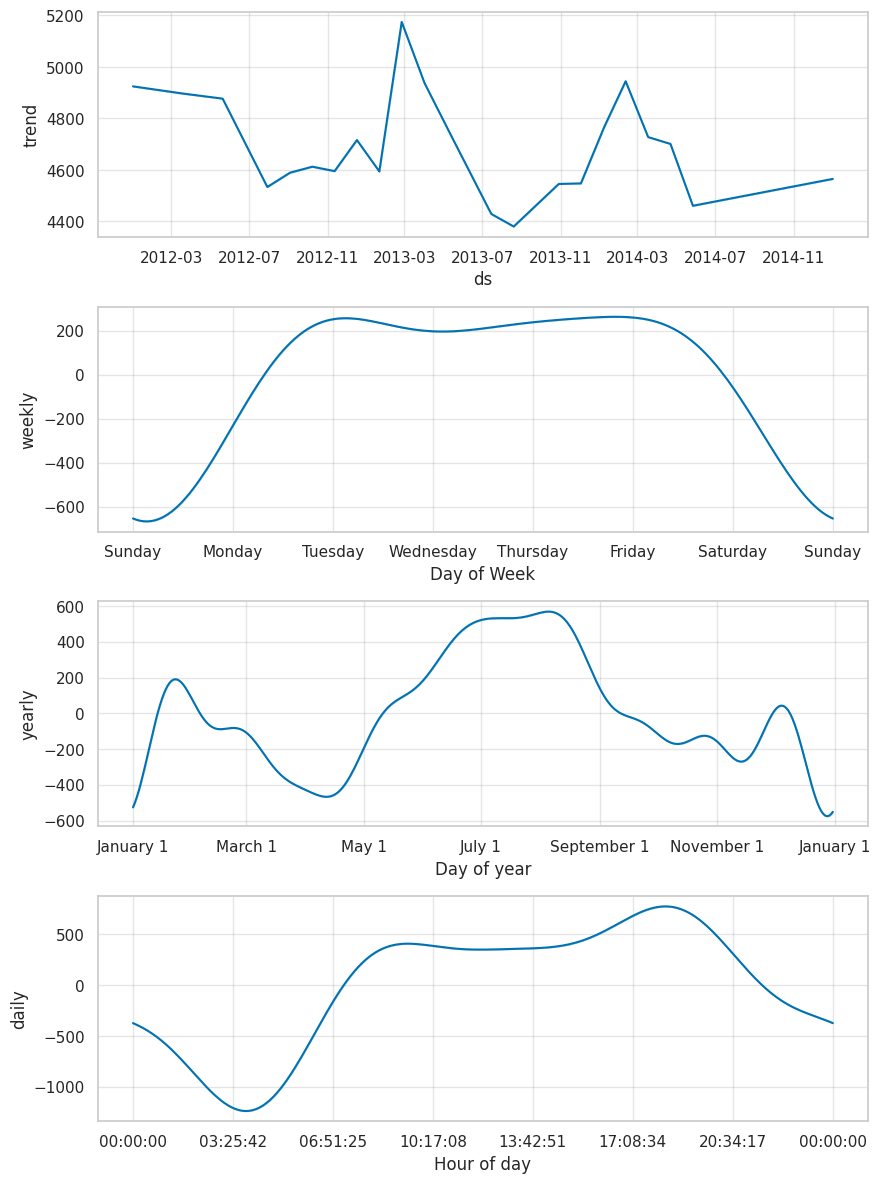

In [ ]:
# Trend, yearly, weekly, and daily panels (same units as Demand).
vic_forecast = vic_model.predict(prophet_vic)
vic_model.plot_components(vic_forecast);

Reading `plot_components(vic_forecast)`:

- **Trend** — the slow-moving baseline Prophet keeps after smoothing out seasonal swings. Demand stays in a fairly narrow band over 2012–2014, matching the time plot.
- **Yearly** — average adjustment by time of year. **Winter** (June–August in Melbourne) sits above trend; **autumn** (March–April) dips below. Summer hot-day spikes add variance but do not dominate the average curve.
- **Weekly** — weekday demand is above trend; **Saturday** and **Sunday** sit well below — the same weekend effect visible on the weekly seasonal plot.
- **Daily** — within-day cycle in **MWh**. Demand is lowest around **4 AM**, rises through the morning, and peaks around **6 PM** — the intraday shape from the daily seasonal plot, now on one smooth curve.
- Because Prophet **averages** across all observations, use the seasonal plots above to spot unusual days or broken years; use Prophet for the typical daily, weekly, and yearly structure a forecaster would reuse.


## Recap

- A **time plot** shows the long-run view — trend and overall seasonality over calendar time.
- **Prophet `plot_components`** splits trend from seasonal effects — one smooth curve per frequency (yearly for monthly or quarterly series; daily, weekly, and yearly for half-hourly demand).
- A **seasonal plot** stacks each season cycle on the same axes — ideal for spotting broken years and sub-daily patterns that a time plot hides.
